We want to take in the fullest_df file from the adata conversion pile line. This is so that we can use the metadata embedded by that pipeline, but also perform some additional ratio calculations prior to normalization.

For this we will do the following:

Calculate pRB:RB ratio in an open ended way so that we can adapt that calculation to other ratios as required

Convert to Adata object with appropriate metadata embedding

Z-normalize the data for possible future use

Plot the pRB:RB ratio so that we can eyeball a cutoff, consider adding in an actual calculation to make this determination

Define a pRB:RB high and pRB:RB low population based off this determined cutoff

Calculate the proportion of all cells which fall within the two catagories

Plot the distribution of cells within these two catagories as a function of drug dose per prior work by Jolene

In [ ]:
import sys, os
# Adjust depth based on notebook location relative to project root
_src_path = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'src'))
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from project_config import load_config

config    = load_config()
base_dir  = config['base_dir']
well_list = config['well_list']
well_meta = config.get('well_metadata', {})

print(f'Active experiment: {config.get("experiment_name", config.get("experiment_key", "?"))}')
print(f'Base dir: {base_dir}')

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.preprocessing import StandardScaler
from scipy.stats import scoreatpercentile

sns.set(style="whitegrid")
plt.rcParams['pdf.fonttype'] = 42


Intial import of fullest_DF

In [2]:
fullest_path = r"D:\Lauryn\Liposarcoma 2025\LPS_246_Alp_Abema_Co_Treat\fullest_df.csv"
fullest_df = pd.read_csv(fullest_path)

In [4]:
fullest_df.columns

Index(['Unnamed: 0', 'Unnamed: 0.1', 'label', 'nuc_area', 'centroid-0',
       'centroid-1', 'orientation', 'major_axis_length', 'minor_axis_length',
       'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'R0_DNA_nuc_mean',
       'R0_pRb_nuc_mean', 'R0_Rb_nuc_mean', 'R1_DNA_nuc_mean',
       'R1_pS6_nuc_mean', 'R1_S6_nuc_mean', 'R1_CDK2_nuc_mean', 'nuc_mask',
       'ring_area', 'R0_DNA_ring_mean', 'R0_pRb_ring_mean', 'R0_Rb_ring_mean',
       'R1_DNA_ring_mean', 'R1_pS6_ring_mean', 'R1_S6_ring_mean',
       'R1_CDK2_ring_mean', 'ring_mask', 'R0_DNA_total_nuc_protein',
       'R0_pRb_total_nuc_protein', 'R0_Rb_total_nuc_protein',
       'R1_DNA_total_nuc_protein', 'R1_pS6_total_nuc_protein',
       'R1_S6_total_nuc_protein', 'R1_CDK2_total_nuc_protein',
       'R0_DNA_nuc_cyto_ratio', 'R0_pRb_nuc_cyto_ratio',
       'R0_Rb_nuc_cyto_ratio', 'R1_DNA_nuc_cyto_ratio',
       'R1_pS6_nuc_cyto_ratio', 'R1_S6_nuc_cyto_ratio',
       'R1_CDK2_nuc_cyto_ratio', 'well', 'dose', 'treatment', 'sample_ID']

Calculate pRB:RB ratio prior to any normalization

In [6]:
# Drop any cells missing pRB/RB intensities
fullest_df = fullest_df.dropna(subset=["R0_pRb_nuc_mean", "R0_Rb_nuc_mean"])

# Raw pRB/RB ratio
fullest_df["pRB_rB_ratio"] = fullest_df["R0_pRb_nuc_mean"] / fullest_df["R0_Rb_nuc_mean"]

#Drop any cells missing pS6/S6 intensities, then compute ratio ---
fullest_df = fullest_df.dropna(subset=["R1_pS6_nuc_mean", "R1_S6_nuc_mean"])
fullest_df["pS6_S6_ratio"] = fullest_df["R1_pS6_nuc_mean"] / fullest_df["R1_S6_nuc_mean"]

Convert to adata object and z-normalize

In [7]:
# Drop columns that you don't need - Preparation for conversion to AnnData object
fullest_df = fullest_df.drop(columns=["Unnamed: 0", "Unnamed: 0.1", "bbox-0", "bbox-1", "bbox-2", "bbox-3", "nuc_mask", "ring_mask", "ring_area"])
columns_to_drop = ["Unnamed: 0", "Unnamed: 0.1", "bbox-0", "bbox-1", "bbox-2", "bbox-3", "nuc_mask", "ring_mask", "ring_area"]
# Extract metadata columns and store them in a separate dataframe
metadata = fullest_df[["label", "well", "sample_ID", "treatment", "dose", "centroid-0", "centroid-1"]]
# Remove metadata columns from the main dataframe
fullest_df = fullest_df.drop(columns=["label", "well", "sample_ID", "treatment", "dose", "centroid-0", "centroid-1"])

In [8]:
# Definition to Normalize the dataframe by z-score

def standardizeColumns(df):
    df = df.copy()
    df.iloc[:,:] = df.iloc[:,:].apply(lambda x: (x-x.mean())/ x.std(), axis=0)
    return df

In [9]:
#Z normalize the data
standard_df = standardizeColumns(fullest_df)

In [10]:
import anndata as ad

# Convert the pandas dataframe to an anndata object
standard_adata = ad.AnnData(standard_df)
# Add metadata back to the anndata object
standard_adata.obs = metadata.copy()
standard_adata.obs_names = [f'c_{i}' for i in standard_adata.obs_names]

#Save the entire adata file
adata_save_path = os.path.join(base_dir, 'standard_adata.h5ad')
standard_adata.write_h5ad(adata_save_path)

Plot pRB:RB as a histogram to start to eyeball a cutoff

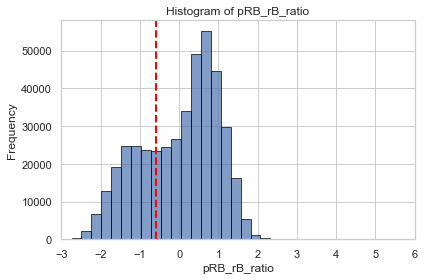

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_var_hist(
    adata,
    var_key,
    bins=50,
    vline=None,
    figsize=(6,4),
    title=None,
    xmin=None,
    xmax=None
):

    # Case 1: Plot a column from adata.var
    if var_key in adata.var.columns:
        data = adata.var[var_key].values

    # Case 2: Plot expression values for a gene (from adata.X)
    elif var_key in adata.var_names:
        idx = list(adata.var_names).index(var_key)
        # Handle sparse matrices if needed
        if hasattr(adata.X, "toarray"):
            data = adata.X[:, idx].toarray().flatten()
        else:
            data = np.array(adata.X[:, idx]).flatten()
    else:
        raise ValueError(
            f"'{var_key}' is not found in adata.var.columns or adata.var_names."
        )

    plt.figure(figsize=figsize)
    plt.hist(data, bins=bins, edgecolor="black", alpha=0.7)

    # Optional vertical reference line
    if vline is not None:
        plt.axvline(vline, color="red", linestyle="--", linewidth=2)

    # Set x-axis limits if provided
    if xmin is not None or xmax is not None:
        plt.xlim(left=xmin, right=xmax)

    plt.xlabel(var_key)
    plt.ylabel("Frequency")
    plt.title(title if title else f"Histogram of {var_key}")
    plt.tight_layout()
    plt.show()

plot_var_hist(
    standard_adata,
    var_key="pRB_rB_ratio",
    vline=-0.6, ###This is our test cutoff set point, we can modify this value to eyeball the cutoff value to use downstream
    xmin=-3,
    xmax=6
)


Next we want to define a new .obs column for calling pRB:RB high vs low cells. We will use the value we tested above to set that call.

In [12]:
import numpy as np

def assign_pRB_call_from_varnames(
    adata,
    var_key="pRB_rB_ratio",
    cutoff=0, #default cut off if not specified below
    new_column="pRB_call",
    high_label="pRB_high",
    low_label="pRB_low"
):
    """
    Assigns pRB call labels to adata.obs based on a cutoff applied to a feature
    whose name is stored in adata.var_names. The actual data are taken from
    adata.X[:, feature_index].
    """

    # Check that the feature exists in adata.var_names
    if var_key not in adata.var_names:
        raise ValueError(f"'{var_key}' is not found in adata.var_names.")

    # Identify the column index for this feature
    idx = list(adata.var_names).index(var_key)

    # Extract the feature values for all cells
    # Support sparse or dense matrices
    if hasattr(adata.X, "toarray"):
        values = adata.X[:, idx].toarray().flatten()
    else:
        values = np.array(adata.X[:, idx]).flatten()

    # Apply classification
    call = np.where(values > cutoff, high_label, low_label)

    # Save results in adata.obs
    adata.obs[new_column] = call

    print(f"Added '{new_column}' to adata.obs using cutoff = {cutoff}.")
    print(f"Counts → {high_label}: {(call==high_label).sum()},  {low_label}: {(call==low_label).sum()}")

    
assign_pRB_call_from_varnames(
    standard_adata,
    var_key="pRB_rB_ratio",
    cutoff=-0.6 # enter cut off number
)


Added 'pRB_call' to adata.obs using cutoff = -0.6.
Counts → pRB_high: 299792,  pRB_low: 124924


In [13]:
standard_adata.obs

,label,well,sample_ID,treatment,dose,centroid-0,centroid-1,pRB_call
c_0,12,B02,1.0,Alp,0uM,11.220994,2962.099448,pRB_high
c_1,13,B02,1.0,Alp,0uM,5.783784,3108.259459,pRB_high
c_2,14,B02,1.0,Alp,0uM,7.675325,3207.640693,pRB_high
c_3,15,B02,1.0,Alp,0uM,14.756522,3243.951304,pRB_high
c_4,16,B02,1.0,Alp,0uM,14.794286,3501.584762,pRB_high
...,...,...,...,...,...,...,...,...
c_424711,8919,G08,21.0,Alp + Abema,20uM + 50nM,6846.177596,1409.319672,pRB_low
c_424712,8922,G08,21.0,Alp + Abema,20uM + 50nM,6848.025707,1550.149100,pRB_low
c_424713,8923,G08,21.0,Alp + Abema,20uM + 50nM,6848.505587,3733.086592,pRB_low
c_424714,8926,G08,21.0,Alp + Abema,20uM + 50nM,6849.610390,4470.207792,pRB_high


pRB:RB high and low labeling has now been done. We need to extract information from treatment and dose for plotting purposes.

In [14]:
import pandas as pd

def add_dose_columns(
    adata,
    treatment_col="treatment",
    dose_col="dose",
    alp_col="Alp_dose",
    abema_col="Abema_dose",
    zero_dose="0uM"
):
    """
    Parse treatment and dose columns in adata.obs to create Alp_dose and Abema_dose.

    Assumes:
      - treatment is either "Alp" or "Alp + Abema"
      - dose is either:
          - "Xunit"              (for Alp only)
          - "Xunit + Yunit"      (for Alp + Abema)
    """

    obs = adata.obs

    def _parse_row(row):
        treatment = str(row[treatment_col]).strip()
        dose_str = str(row[dose_col]).strip()

        # Default values
        alp_dose = zero_dose
        abema_dose = zero_dose

        if treatment == "Alp":
            # Single dose applies to Alp only
            alp_dose = dose_str
            abema_dose = zero_dose

        elif treatment == "Alp + Abema":
            # Expect "Alp_dose + Abema_dose"
            if "+" in dose_str:
                parts = [p.strip() for p in dose_str.split("+", 1)]
                if len(parts) == 2:
                    alp_dose, abema_dose = parts[0], parts[1]
                else:
                    # Fallback if formatting is weird
                    alp_dose = dose_str
                    abema_dose = zero_dose
            else:
                # If someone forgot the '+', treat it as Alp-only
                alp_dose = dose_str
                abema_dose = zero_dose
        else:
            # If an unexpected treatment appears, leave defaults
            pass

        return pd.Series({alp_col: alp_dose, abema_col: abema_dose})

    doses = obs.apply(_parse_row, axis=1)
    adata.obs[alp_col] = doses[alp_col]
    adata.obs[abema_col] = doses[abema_col]

    print(f"Added '{alp_col}' and '{abema_col}' to adata.obs.")
    print(adata.obs[[treatment_col, dose_col, alp_col, abema_col]].head())


add_dose_columns(standard_adata)

Added 'Alp_dose' and 'Abema_dose' to adata.obs.
    treatment dose Alp_dose Abema_dose
c_0       Alp  0uM      0uM        0uM
c_1       Alp  0uM      0uM        0uM
c_2       Alp  0uM      0uM        0uM
c_3       Alp  0uM      0uM        0uM
c_4       Alp  0uM      0uM        0uM


Now that we have our pRB:RB high and low defined, plus our treatment and dosing information parsed, we can look for the total number of cells in a given treatment and dose combination and then calculate the proportion of those cells which are high for pRB:RB

In [15]:
standard_adata.obs

,label,well,sample_ID,treatment,dose,centroid-0,centroid-1,pRB_call,Alp_dose,Abema_dose
c_0,12,B02,1.0,Alp,0uM,11.220994,2962.099448,pRB_high,0uM,0uM
c_1,13,B02,1.0,Alp,0uM,5.783784,3108.259459,pRB_high,0uM,0uM
c_2,14,B02,1.0,Alp,0uM,7.675325,3207.640693,pRB_high,0uM,0uM
c_3,15,B02,1.0,Alp,0uM,14.756522,3243.951304,pRB_high,0uM,0uM
c_4,16,B02,1.0,Alp,0uM,14.794286,3501.584762,pRB_high,0uM,0uM
...,...,...,...,...,...,...,...,...,...,...
c_424711,8919,G08,21.0,Alp + Abema,20uM + 50nM,6846.177596,1409.319672,pRB_low,20uM,50nM
c_424712,8922,G08,21.0,Alp + Abema,20uM + 50nM,6848.025707,1550.149100,pRB_low,20uM,50nM
c_424713,8923,G08,21.0,Alp + Abema,20uM + 50nM,6848.505587,3733.086592,pRB_low,20uM,50nM
c_424714,8926,G08,21.0,Alp + Abema,20uM + 50nM,6849.610390,4470.207792,pRB_high,20uM,50nM


In [16]:
import pandas as pd

def summarize_pRB_by_treatment(
    adata,
    alp_col="Alp_dose",
    abema_col="Abema_dose",
    call_col="pRB_call",
    high_label="pRB_high"
):
    """
    For each unique (Alp_dose, Abema_dose) combination, compute:
      - total number of cells
      - number of pRB_high cells
      - fraction of pRB_high cells

    Returns a pandas DataFrame.
    """

    obs = adata.obs

    # Group by treatment type (Alp_dose + Abema_dose)
    grouped = (
        obs
        .groupby([alp_col, abema_col])
        .agg(
            total_cells = (call_col, "size"),
            pRB_high_cells = (call_col, lambda s: (s == high_label).sum())
        )
        .reset_index()
    )

    # Add proportion column
    grouped["pRB_high_fraction"] = grouped["pRB_high_cells"] / grouped["total_cells"]

    return grouped

treatment_summary = summarize_pRB_by_treatment(standard_adata)
print(treatment_summary)


   Alp_dose Abema_dose  total_cells  pRB_high_cells  pRB_high_fraction
0     0.5uM        0uM        21936           20406           0.930252
1     0.5uM       10nM        10902            9707           0.890387
2     0.5uM       50nM        20857           15874           0.761087
3       0uM        0uM        33637           25279           0.751524
4       0uM       10nM        21300           18898           0.887230
5       0uM       50nM        20794           10557           0.507695
6      10uM        0uM        19922           14833           0.744554
7      10uM       10nM        20735           13558           0.653870
8      10uM       50nM        20206            5406           0.267544
9       1uM        0uM        22824           20793           0.911015
10      1uM       10nM        22176           19350           0.872565
11      1uM       50nM        21549           14271           0.662258
12    2.5uM        0uM        23356           20661           0.884612
13    

This is the plotting for the pRB high proportion information

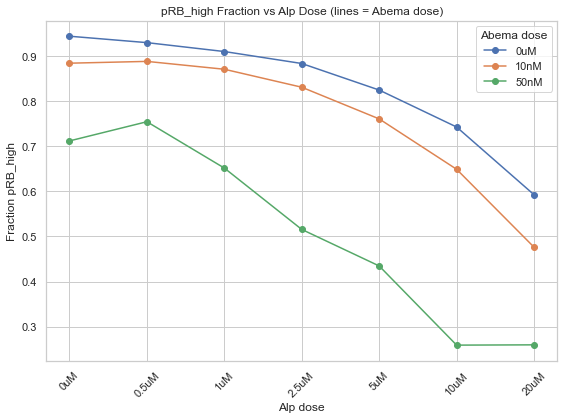

In [58]:
import matplotlib.pyplot as plt

def plot_pRB_fraction_by_dose(
    df,
    alp_col="Alp_dose",
    abema_col="Abema_dose",
    frac_col="pRB_high_fraction",
    figsize=(8,6)
):
    """
    Plots pRB_high_fraction on the y-axis against Alp_dose on the x-axis,
    with one line per unique Abema_dose.
    """

    # Sort Alp doses in natural numeric order if possible
    # (Only works if doses end with units like "uM", "nM")
    def extract_numeric(x):
        try:
            return float(x.replace("uM", "").replace("nM", "").strip())
        except:
            return x

    df_sorted = df.copy()
    df_sorted["__alp_numeric"] = df_sorted[alp_col].apply(extract_numeric)
    df_sorted = df_sorted.sort_values("__alp_numeric")

    # Plot
    plt.figure(figsize=figsize)

    for abema_dose, sub in df_sorted.groupby(abema_col):
        plt.plot(
            sub[alp_col],
            sub[frac_col],
            marker="o",
            label=str(abema_dose)
        )

    plt.xlabel("Alp dose")
    plt.ylabel("Fraction pRB_high")
    plt.title("pRB_high Fraction vs Alp Dose (lines = Abema dose)")
    plt.legend(title="Abema dose")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_pRB_fraction_by_dose(treatment_summary)

For the proportional fold change plot, we want to normalize each of the Abema treatment groups to their Alp 0uM dose. This will result in a plot where each line starts at 1.0 and diverges in a more interpretable way.

In [59]:
def normalize_pRB_fraction(
    df,
    alp_zero="0uM",
    alp_col="Alp_dose",
    abema_col="Abema_dose",
    frac_col="pRB_high_fraction",
    norm_col="pRB_high_norm"
):
    """
    Adds a column to df that normalizes pRB_high_fraction for each Abema_dose
    relative to the fraction observed at Alp_dose == alp_zero.
    """

    df = df.copy()

    # Dictionary: Abema_dose → baseline pRB_high_fraction at Alp = 0uM
    baselines = (
        df[df[alp_col] == alp_zero]
        .set_index(abema_col)[frac_col]
        .to_dict()
    )

    # Apply normalization row-wise
    def compute_norm(row):
        abema = row[abema_col]
        baseline = baselines.get(abema, None)
        if baseline is None or baseline == 0:
            return None  # no baseline available
        return row[frac_col] / baseline

    df[norm_col] = df.apply(compute_norm, axis=1)

    return df


treatment_summary = summarize_pRB_by_treatment(standard_adata)

treatment_summary = normalize_pRB_fraction(treatment_summary)
print(treatment_summary)


   Alp_dose Abema_dose  total_cells  pRB_high_cells  pRB_high_fraction  \
0     0.5uM        0uM        21936           20394           0.929705   
1     0.5uM       10nM        10904            9684           0.888114   
2     0.5uM       50nM        20858           15735           0.754387   
3       0uM        0uM        22900           21616           0.943930   
4       0uM       10nM        21300           18832           0.884131   
5       0uM       50nM        10446            7436           0.711851   
6      10uM        0uM        19939           14808           0.742665   
7      10uM       10nM        20743           13462           0.648990   
8      10uM       50nM        20214            5240           0.259226   
9       1uM        0uM        22825           20770           0.909967   
10      1uM       10nM        22182           19314           0.870706   
11      1uM       50nM        21550           14044           0.651694   
12    2.5uM        0uM        23361   

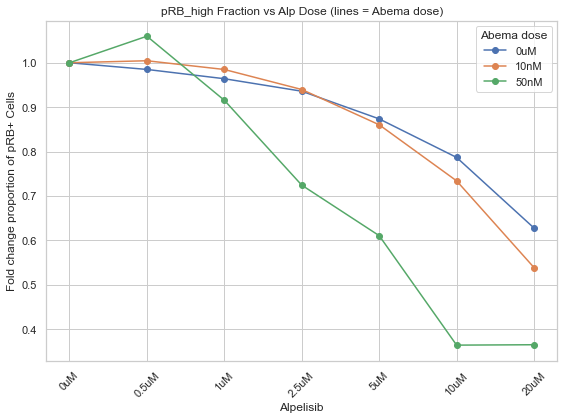

In [60]:
import matplotlib.pyplot as plt

def plot_pRB_norm_by_dose(
    df,
    alp_col="Alp_dose",
    abema_col="Abema_dose",
    frac_col="pRB_high_norm",
    figsize=(8,6)
):

    # Sort Alp doses in natural numeric order if possible
    # (Only works if doses end with units like "uM", "nM")
    def extract_numeric(x):
        try:
            return float(x.replace("uM", "").replace("nM", "").strip())
        except:
            return x

    df_sorted = df.copy()
    df_sorted["__alp_numeric"] = df_sorted[alp_col].apply(extract_numeric)
    df_sorted = df_sorted.sort_values("__alp_numeric")

    # Plot
    plt.figure(figsize=figsize)

    for abema_dose, sub in df_sorted.groupby(abema_col):
        plt.plot(
            sub[alp_col],
            sub[frac_col],
            marker="o",
            label=str(abema_dose)
        )

    plt.xlabel("Alpelisib")
    plt.ylabel("Fold change proportion of pRB+ Cells")
    plt.title("pRB_high Fraction vs Alp Dose (lines = Abema dose)")
    plt.legend(title="Abema dose")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_pRB_norm_by_dose(treatment_summary)

Saving graphs as JPEG

In [67]:
import os
import matplotlib.pyplot as plt

# --------------------------------------------------
# Base output folder
# --------------------------------------------------
base_dir = r"D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_Co_Treat_Dec_2025\cotreatment_graphs"

# Make subfolders
jpeg_dir = os.path.join(base_dir, "jpeg")
tiff_dir = os.path.join(base_dir, "tiff")
pdf_dir  = os.path.join(base_dir, "pdf")
for d in (jpeg_dir, tiff_dir, pdf_dir):
    os.makedirs(d, exist_ok=True)

# --------------------------------------------------
# Temporarily disable plt.show() to prevent blank saves
# --------------------------------------------------
_original_show = plt.show
plt.show = lambda *args, **kwargs: None

def save_all_formats(plot_func, stem):
    """Run a plotting function once and save to jpeg/tiff/pdf subfolders."""
    plot_func(treatment_summary)

    plt.savefig(os.path.join(jpeg_dir, f"{stem}.jpeg"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(tiff_dir, f"{stem}.tiff"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(pdf_dir,  f"{stem}.pdf"),  bbox_inches="tight")

    plt.close()

# --------------------------------------------------
# Save both plots in all formats
# --------------------------------------------------
save_all_formats(plot_pRB_fraction_by_dose, "proportion_graph")
save_all_formats(plot_pRB_norm_by_dose, "fold_change_graph")

# --------------------------------------------------
# Restore normal plt.show()
# --------------------------------------------------
plt.show = _original_show

print("Saved all graphs to:")
print(f"  JPEG: {jpeg_dir}")
print(f"  TIFF: {tiff_dir}")
print(f"  PDF : {pdf_dir}")


meta NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped


Saved all graphs to:
  JPEG: D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_Co_Treat_Dec_2025\cotreatment_graphs\jpeg
  TIFF: D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_Co_Treat_Dec_2025\cotreatment_graphs\tiff
  PDF : D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_Co_Treat_Dec_2025\cotreatment_graphs\pdf
